In [141]:
import os
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
from nltk.tokenize import sent_tokenize
import nltk
nltk.download("punkt")
nltk.download("stopwords")
import re
from sklearn.impute import SimpleImputer
from sentence_transformers import SentenceTransformer
import os
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import shap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import ast
import nltk
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

[nltk_data] Downloading package punkt to /Users/bao/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/bao/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## PREPROCESSING

In [4]:
# Thư mục chứa scripts
folder_path = "./imsdbfilmscripts"

# Danh sách để lưu dữ liệu
data = []

# Duyệt tất cả file .txt trong folder
for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        movie_name = os.path.splitext(filename)[0]  # tên file bỏ .txt
        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            movie_script = f.read().replace("\n", " ")  # chuyển xuống dòng thành space
        data.append([movie_name, movie_script])

# Tạo DataFrame
df = pd.DataFrame(data, columns=["movie_name", "movie_script"])

# Xuất ra CSV
#df.to_csv("movies_scripts.csv", index=False, encoding="utf-8")
print("Done! CSV saved as movies_scripts.csv")

Done! CSV saved as movies_scripts.csv


In [5]:
df["movie_name"] = df["movie_name"].str.replace("-", " ")

In [6]:
df

,movie_name,movie_script
0,Midnight Express,MIDNIG...
1,Speed,Speed Script at IMSDb. This script was...
2,Big Eyes,...
3,Warrior,WARRIOR ...
4,Hellraiser Hellseeker,HELLRAISER: HELLSEEKER ...
...,...,...
1160,Silver Linings Playbook,SILVER LININGS...
1161,"Prestige, The",THE P...
1162,Four Rooms,"""FOUR R..."
1163,"Theory of Everything, The",THE THEORY...


In [7]:
ratings = pd.read_csv("data/title.ratings.tsv", sep="\t")
basics = pd.read_csv("data/title.basics.tsv", sep="\t", low_memory=False)

# Keep only movies
basics = basics[basics["titleType"] == "movie"]

# Merge ratings with titles
imdb = basics.merge(ratings, on="tconst")

# Keep the most popular version for each exact title
imdb_unique = imdb.sort_values("numVotes", ascending=False).drop_duplicates("primaryTitle")

In [8]:
df = df.merge(
    imdb_unique[["primaryTitle", "averageRating"]],
    left_on="movie_name",
    right_on="primaryTitle",
    how="left"
)

# Remove the extra column
df = df.drop(columns=["primaryTitle"])

In [9]:
df

,movie_name,movie_script,averageRating
0,Midnight Express,MIDNIG...,7.5
1,Speed,Speed Script at IMSDb. This script was...,7.3
2,Big Eyes,...,6.9
3,Warrior,WARRIOR ...,8.1
4,Hellraiser Hellseeker,HELLRAISER: HELLSEEKER ...,NaN
...,...,...,...
1160,Silver Linings Playbook,SILVER LININGS...,7.7
1161,"Prestige, The",THE P...,NaN
1162,Four Rooms,"""FOUR R...",6.7
1163,"Theory of Everything, The",THE THEORY...,NaN


In [10]:
df.dtypes

movie_name           str
movie_script         str
averageRating    float64
dtype: object

In [11]:
df.isna().sum()

movie_name         0
movie_script       0
averageRating    359
dtype: int64

In [12]:
imdb_titles = imdb_unique["primaryTitle"].tolist()

# Fuzzy match function
def fuzzy_match(title, threshold=90):
    match = process.extractOne(title, imdb_titles, scorer=fuzz.ratio)
    if match and match[1] >= threshold:
        # Get rating
        matched_title = match[0]
        rating = imdb_unique.loc[
            imdb_unique["primaryTitle"] == matched_title, "averageRating"
        ].values[0]
        return rating
    return None

# Apply fuzzy matching only for missing ratings
missing_mask = df["averageRating"].isna()
df.loc[missing_mask, "averageRating"] = df.loc[missing_mask, "movie_name"].apply(lambda x: fuzzy_match(str(x)))

In [13]:
df.isna().sum()

movie_name         0
movie_script       0
averageRating    284
dtype: int64

In [14]:
# Drop rows with null ratings
df = df.dropna(subset=["averageRating"])

# Reset index (optional)
df = df.reset_index(drop=True)


In [15]:
df.head()

,movie_name,movie_script,averageRating
0,Midnight Express,MIDNIG...,7.5
1,Speed,Speed Script at IMSDb. This script was...,7.3
2,Big Eyes,...,6.9
3,Warrior,WARRIOR ...,8.1
4,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8


In [16]:
def preprocess_script(script: str) -> str:
    # Remove INT. / EXT. scene headings (common screenplay format)
    script = re.sub(r"^\s*(INT\.|EXT\.)[^\n]*\n", "", script,
                    flags=re.MULTILINE | re.IGNORECASE)

    # Remove character cue lines: lines that are ALL CAPS (and optional spaces)
    # Typical pattern: "    ANDY" or "JOKER (V.O.)" on its own line
    script = re.sub(r"^\s*[A-Z][A-Z\s\.\(\)\']{2,}\s*$", "",
                    script, flags=re.MULTILINE)

    # Remove parentheticals like (V.O.), (CONT'D), (quietly)
    script = re.sub(r"\(.*?\)", "", script)
    script = re.sub(r'</?b>', '', script)
    script = re.sub(r'<!--.*?-->', '', script, flags=re.DOTALL)
    
    # Remove C-style comments /* ... */
    script = re.sub(r'/\*.*?\*/', '', script, flags=re.DOTALL)
    # Remove JavaScript single-line comments // ...
    script = re.sub(r'//.*', '', script)
    # Strip leading/trailing whitespace and normalize spaces
    script = re.sub(r'\s+', ' ', script).strip()

    # Remove lines that look like screenplay headers or transitions
    script = re.sub(r"^\s*(FADE IN|FADE OUT|CUT TO|DISSOLVE TO|SMASH CUT).*$",
                    "", script, flags=re.MULTILINE | re.IGNORECASE)

    # Collapse multiple blank lines into a single newline
    script = re.sub(r"\n{2,}", "\n", script)

    # Strip leading/trailing whitespace from each line
    lines = [line.strip() for line in script.splitlines()]
    script = " ".join(line for line in lines if line)

    # Lowercase for uniformity
    script = script.lower()

    # Remove extra internal whitespace
    script = re.sub(r"\s+", " ", script).strip()

    return script

In [17]:
df["clean_script"] = df["movie_script"].apply(preprocess_script)

In [18]:
def segment_sentences(text: str) -> list[str]:
    sentences = nltk.sent_tokenize(text)
    # Filter out very short fragments (< 10 characters) that add no signal
    sentences = [s.strip() for s in sentences if len(s.strip()) >= 10]
    return sentences

In [19]:
# print(type(df["sentences"].iloc[0]))   # is it a list or a string?
# print(df["sentences"].iloc[0])

In [20]:
df["sentences"] = df["clean_script"].apply(segment_sentences)

In [21]:
for s in df["sentences"][0]:
    print(f"{s}: {len(s)}")

midnight express screenplay by oliver stone based on the autobiography by billy hayes with william hoffer revised draft june, 1977 prologue black screen - superimpose: the following is based on a true story.: 207
it october 6, 1970 istanbul, turkey - sound under, sharp: crackle - rip - snip... fade in: a set of clothes on a hotel room bed -- trenchcoat, bulky white turtle-neck sweater, t-shirt, jeans, western style boots.: 212
sounds continue, accentuated.: 29
move across open travel bags on the bed.: 40
clothes, possessions.: 21
continue across furniture, washbasin, toilet...a large room, high old ceilings and windows suggesting ancient europe & design, a haunting greenish afternoon light.: 163
we move to hands, tight - drawing out a strip of adhesive tape, scissors move in tight...snip!: 94
underarm, tight.: 16
tape being laid over it.: 24
back of shoulder.: 17
tape going on.: 14
bellybutton, tight.: 19
tape going then: a harsh rip!: 29
sound and the tape comes off the bellybutton.: 

In [22]:
df

,movie_name,movie_script,averageRating,clean_script,sentences
0,Midnight Express,MIDNIG...,7.5,midnight express screenplay by oliver stone ba...,[midnight express screenplay by oliver stone b...
1,Speed,Speed Script at IMSDb. This script was...,7.3,speed script at imsdb. this script was brought...,"[speed script at imsdb., this script was broug..."
2,Big Eyes,...,6.9,big eyes written by scott alexander & larry ka...,[big eyes written by scott alexander & larry k...
3,Warrior,WARRIOR ...,8.1,"warrior written by gavin o'connor, anthony tam...","[warrior written by gavin o'connor, anthony ta..."
4,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8,hannah and her sisters hannah and her sisters ...,[hannah and her sisters hannah and her sisters...
...,...,...,...,...,...
876,Smashed,SMASHED ...,6.7,smashed written by james ponsoldt & susan burk...,[smashed written by james ponsoldt & susan bur...
877,Wild Wild West,Rev. ...,4.9,rev. 06/15/98 rev. 07/01/98 rev. 08/28/98 rev....,"[06/15/98 rev., 07/01/98 rev., 08/28/98 rev., ..."
878,Misery,Misery - by William Goldman <b><!-- </b>if (...,7.8,"misery - by william goldman ""misery"" by willia...","[misery - by william goldman ""misery"" by willi..."
879,Silver Linings Playbook,SILVER LININGS...,7.7,silver linings playbook written by david o. ru...,[silver linings playbook written by david o. r...


In [23]:
from itertools import chain

def build_embeddings_fast(df: pd.DataFrame,
                          sbert_model: SentenceTransformer) -> pd.DataFrame:
    
    all_sentences   = df["sentences"].tolist()
    sentence_counts = [len(s) for s in all_sentences]
    flat_sentences  = list(chain.from_iterable(all_sentences))

    print(f"  Encoding {len(flat_sentences)} sentences across "
          f"{len(df)} movies in one batch ...")

    # Single encode call for everything
    all_embeddings = sbert_model.encode(
        flat_sentences,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True)

    # Split back per movie
    split_embeddings = np.split(all_embeddings, np.cumsum(sentence_counts)[:-1])

    df["sent_emb"]     = [e.tolist() for e in split_embeddings]

    return df

In [24]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9123.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
df = build_embeddings_fast(df, sbert_model)

  Encoding 2132910 sentences across 881 movies in one batch ...


Batches: 100%|██████████| 33327/33327 [22:07<00:00, 25.11it/s] 


In [26]:
# Define good vs bad rating
df["rating_label"] = df["averageRating"].apply(lambda x: 1 if x >= 7.5 else 0)

In [27]:
df.dtypes

movie_name           str
movie_script         str
averageRating    float64
clean_script         str
sentences         object
sent_emb          object
rating_label       int64
dtype: object

In [28]:
#df.to_csv("results/movies_scripts_ratings.csv", index=False, encoding="utf-8")

In [32]:
df.head(5)

,movie_name,movie_script,averageRating,clean_script,sentences,sent_emb,rating_label
0,Midnight Express,MIDNIG...,7.5,midnight express screenplay by oliver stone ba...,[midnight express screenplay by oliver stone b...,"[[-0.02682011015713215, 0.02455146051943302, -...",1
1,Big Eyes,...,6.9,big eyes written by scott alexander & larry ka...,[big eyes written by scott alexander & larry k...,"[[-0.03220375254750252, 0.022299902513623238, ...",0
2,Warrior,WARRIOR ...,8.1,"warrior written by gavin o'connor, anthony tam...","[warrior written by gavin o'connor, anthony ta...","[[-0.11002527922391891, 0.0337693877518177, 0....",1
3,Hannah and Her Sisters,<b><!-- </b> <b>/* </b>Break-out-of-frames ...,7.8,hannah and her sisters hannah and her sisters ...,[hannah and her sisters hannah and her sisters...,"[[-0.001566486433148384, -0.020226923748850822...",1
4,Cinema Paradiso,CINEMA PARADISO by Giuseppe Tornatore \t\t...,8.5,cinema paradiso by giuseppe tornatore cinema p...,[cinema paradiso by giuseppe tornatore cinema ...,"[[-0.04684927314519882, 0.030328093096613884, ...",1


In [33]:
df = df[df["sentences"].apply(len) > 2].reset_index(drop=True)
print(f"Remaining movies: {len(df)}")

Remaining movies: 860


In [34]:
lengths = df['sent_emb'].apply(len)
mean_length = lengths.mean()
mean_length

np.float64(2480.094186046512)

## PREPARE

In [173]:
def pad_to_length(emb, length):
    emb = np.array(emb, dtype=np.float32)
    if len(emb) >= length:
        return emb[:length] #if sentence is too long (shorten it into length)
    pad = np.zeros((length - len(emb), emb.shape[1]), dtype=np.float32) #if it is too short, extend it with vector zero
    return np.vstack([emb, pad])
#in the end, all the movie have the same sentence length 

In [174]:
def prepare_tensors(embeddings_list, labels, max_sentences=200):
    padded   = np.stack([pad_to_length(e, max_sentences) for e in embeddings_list]) #same length 
    lengths = torch.tensor([min(len(e), max_sentences) for e in embeddings_list], dtype=torch.long)
    X_tensor = torch.tensor(padded,  dtype=torch.float32) #(n_movie, max_sentences, 384)
    y_tensor = torch.tensor(labels,  dtype=torch.long) #(n_movie,)
    return X_tensor, y_tensor, lengths

In [175]:
embeddings_list = [np.array(emb, dtype=np.float32) for emb in df["sent_emb"]]
labels = df["rating_label"].tolist()

In [177]:
max_sentences = 2480

In [178]:
lengths = [len(emb) for emb in embeddings_list]
print(f"Min  : {min(lengths)}")
print(f"Max  : {max(lengths)}")
print(f"Mean : {np.mean(lengths):.0f}")
print(f"Median: {np.median(lengths):.0f}")

Min  : 60
Max  : 5395
Mean : 2480
Median: 2474


In [224]:
import numpy as np
lengths = [len(emb) for emb in embeddings_list]
short = [(i, l) for i, l in enumerate(lengths) if l < 500]
print(f"Number of movie has < 500 sentences: {len(short)}")
print(short)

Number of movie has < 500 sentences: 1
[(181, 60)]


In [180]:
print(df.iloc[181]['clean_script'])

cellular by larry cohen revised by chris morgan current revisions by j. mackye gruber & eric bress july 16, 2003 titles over yellow background. we pull back to reveal we're looking at the sun. in the distance lie the gorgeous san gabriel mountains and the downtown los angeles skyline. in one long tracking shot, we crane past some trees to reveal the vast expansive homes scattered in the hills of brentwood. homeowners walk dogs, a paperboy chucks papers fr9m a gleaming mountain bike... it's early in the morning, and the landscapers haven't come with their leaf blowers yet. continue booming down to road level to face the resplendent martin residence. we steadicam down the fr ont walk, able to admire the manicured hedges and the black e scalade in the driveway, to the front door decorated with a whimsical placard that reads, "the martins" -- and we pass through the keyhole into the foyer. int. jessica's house - morning we track through the living room, passing framed photos of an athletic

In [181]:
#split the movie 
idx = list(range(len(labels)))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels)

train_emb    = [embeddings_list[i] for i in train_idx]
val_emb      = [embeddings_list[i] for i in val_idx]
train_labels = [labels[i] for i in train_idx]
val_labels   = [labels[i] for i in val_idx]

In [182]:
X_train_t, y_train_t, lengths_train = prepare_tensors(train_emb, train_labels, max_sentences)
X_val_t, y_val_t, lengths_val  = prepare_tensors(val_emb, val_labels, max_sentences)

In [234]:
X_train_t.shape

torch.Size([688, 2480, 384])

In [230]:
lengths_train

tensor([2480, 2277, 2480, 1881, 2027, 2480, 2296, 2480, 2480, 2480, 2437, 2480,
        2480, 1868, 1807, 2480, 2480, 1880, 2107, 2480, 1220, 2480, 2480, 2264,
        1999, 2480, 2480, 2160, 2480, 2480, 2480, 2480, 2480, 1497, 2480, 2333,
        2461, 1551, 2102, 1658, 2100, 2480, 1691, 2480, 2480, 2480, 2480, 1987,
        2480, 1819, 2480, 2480, 2091, 2480, 2480, 2480, 2480, 2480, 1788, 2364,
        2480, 2480, 2199, 2331, 2120, 2480, 2480, 2351, 2480, 2320, 1982, 2480,
        2202, 2480, 2480, 2480, 2276, 2480, 2182, 2023, 2480, 2480, 2037, 2480,
        2480, 2338, 2480, 2480, 2018, 2480, 2473, 2480, 2224, 2480, 2294, 2480,
        1852, 2127, 2480, 2480, 2475, 2333, 1954, 2480, 2480, 2479, 2480, 2480,
        2076, 2344, 2480, 2480, 2480, 2277, 2480, 2480, 1421, 2077, 2480, 2354,
        2418, 2384, 2134, 2173, 1455, 2336, 2257, 2272, 1934, 2072, 2480, 2137,
        2480, 2480, 2480, 1174, 2161, 2203, 2480, 2480, 2480, 2480, 2480, 2480,
        2480, 2480, 2371, 2480, 2057, 24

## CONVOLUTIONAL BACKBONE

In [ ]:
def make_conv_backbone():
    return nn.Sequential(
        nn.Conv1d(384, 128, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
        nn.Conv1d(128,  64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
        nn.Conv1d( 64,  32, kernel_size=3, padding=1), nn.ReLU(),
    ) #(n_movie, 32, 620)

In [226]:
backbone = make_conv_backbone()

In [ ]:
def run_backbone(backbone, x, lengths=None):
    x         = x.transpose(1, 2) #(384, N_sentence)
    feat_maps = backbone(x) #(688 (batch), 32,  620)

    if lengths is not None:
        reduced_lengths = (lengths // 4).clamp(min=1)  # 2480 → 620 after 2 MaxPool
        T    = feat_maps.size(2)
        idx  = torch.arange(T).unsqueeze(0)
        mask = (idx < reduced_lengths.unsqueeze(1)).unsqueeze(1).float() #(n_movie, 1, 620)
        gap  = (feat_maps * mask).sum(dim=2) / mask.sum(dim=2) #global average pooling
    else:
        gap = feat_maps.mean(dim=2) #(688 (batch), 32)

    return gap, feat_maps

## TRAIN BACKBONE

In [ ]:
def train_backbone(backbone, X_tensor, y_tensor, lengths,
                   n_epochs=10, batch_size=8, lr=1e-3):
    n_classes   = len(y_tensor.unique())
    linear_head = nn.Linear(32, n_classes)
    optimizer   = torch.optim.Adam(
        list(backbone.parameters()) + list(linear_head.parameters()), lr=lr
    )
    #treat imbalanced class
    weights = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tensor.numpy())
    weight_tensor = torch.tensor(weights, dtype=torch.float32)
    loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)

    loader = DataLoader(TensorDataset(X_tensor, y_tensor, lengths), batch_size=batch_size, shuffle=True) 
 
    backbone.train()
    linear_head.train()
 
    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
 
        for x_batch, y_batch, l_batch in loader:
            optimizer.zero_grad()
            gap, _  = run_backbone(backbone, x_batch, lengths=l_batch)
            logits  = linear_head(gap)
            loss    = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
 
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
 
        print(f"Epoch {epoch+1:02d} | loss={total_loss/total:.4f} | acc={correct/total:.3f}")
 
    backbone.eval()
    return backbone

In [190]:
n_epochs = 10
batch_size=8
backbone = train_backbone(backbone, X_train_t, y_train_t, lengths_train, n_epochs, batch_size)

Epoch 01 | loss=0.6931 | acc=0.677
Epoch 02 | loss=0.6861 | acc=0.718
Epoch 03 | loss=0.6729 | acc=0.654
Epoch 04 | loss=0.6305 | acc=0.712
Epoch 05 | loss=0.5936 | acc=0.705
Epoch 06 | loss=0.5615 | acc=0.734
Epoch 07 | loss=0.5378 | acc=0.738
Epoch 08 | loss=0.5504 | acc=0.746
Epoch 09 | loss=0.5087 | acc=0.778
Epoch 10 | loss=0.4977 | acc=0.775


## EXTRACT GLOBAL AVERAGE POOLING FEATURES

In [ ]:
def get_gap_features(backbone, X_tensor, lengths):
    backbone.eval()
    with torch.no_grad():
        gap, _ = run_backbone(backbone, X_tensor, lengths=lengths)
    return gap.numpy()

In [192]:
X_train = get_gap_features(backbone, X_train_t, lengths_train)   # (n_train, 32)
X_val   = get_gap_features(backbone, X_val_t, lengths_val)     # (n_val,   32)
y_train = np.array(train_labels)
y_val   = np.array(val_labels)

In [237]:
X_train.shape

(688, 32)

## Logistic Regression + CAM

In [193]:
def fit_logistic_regression(X, y):
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X, y)
    return model

In [ ]:
def get_cam(lr_model, backbone, movie_emb, target_class, max_sentences=200):
    padded = pad_to_length(movie_emb, max_sentences) # (2480, 384)
    x      = torch.tensor(padded, dtype=torch.float32).unsqueeze(0) # (1, 2480, 384)

    backbone.eval()
    with torch.no_grad():
        length = torch.tensor([min(len(movie_emb), max_sentences)], dtype=torch.long) #real length of that movie
        _, feat_maps = run_backbone(backbone, x, lengths=length)
        feat_maps    = feat_maps.squeeze(0).numpy()   # (1, 32, 620)

    weights = lr_model.coef_[0]           # (32,)
    if target_class == 0:
        weights = -weights                # reverse sign for 0

    return np.einsum("k, kt -> t", weights, feat_maps)

In [ ]:
lr_model = fit_logistic_regression(X_train, y_train)
print(f"LR accuracy: {(lr_model.predict(X_val) == y_val).mean():.3f}")
print(classification_report(y_val, lr_model.predict(X_val)))
 
# First moive in validation dataset
target_class = int(val_labels[0])
cam = get_cam(lr_model, backbone, val_emb[0], target_class, max_sentences)
#plt.savefig("cam_attribution.png", dpi=150, bbox_inches="tight")

LR accuracy: 0.640
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       123
           1       0.39      0.45      0.42        49

    accuracy                           0.64       172
   macro avg       0.58      0.58      0.58       172
weighted avg       0.66      0.64      0.65       172



## XGBoost + SHAP

In [196]:
def fit_xgboost(X, y):
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=70/30
    )
    model.fit(X, y)
    return model

In [ ]:
def get_shap_attribution(xgb_model, backbone, X_val_tensor, lengths_val,
                         movie_emb, movie_idx=0, max_sentences=200):
    
    X_val_np  = get_gap_features(backbone, X_val_tensor, lengths_val)   # (n_val, 32)
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_val_np)            # (n_val, 32)
 
    channel_weights = shap_vals[movie_idx]                 # (32,)
 
    padded = pad_to_length(movie_emb, max_sentences)
    x      = torch.tensor(padded, dtype=torch.float32).unsqueeze(0)
    length = torch.tensor([min(len(movie_emb), max_sentences)], dtype=torch.long)
    backbone.eval()
    with torch.no_grad():
        length = torch.tensor([min(len(movie_emb), max_sentences)], dtype=torch.long)
        _, feat_maps = run_backbone(backbone, x, lengths=length)
        feat_maps    = feat_maps.squeeze(0).numpy()        # (32, N/8)
 
    return np.einsum("k, kt -> t", channel_weights, feat_maps)

In [204]:
print("\nFit XGBoost …")
xgb_model = fit_xgboost(X_train, y_train)
print(f"XGB accuracy: {(xgb_model.predict(X_val) == y_val).mean():.3f}")
print(classification_report(y_val, xgb_model.predict(X_val)))

shap_attr = get_shap_attribution(
        xgb_model, backbone, X_val_t, lengths_val,
        movie_emb=val_emb[0], movie_idx=0, max_sentences=max_sentences
    )


Fit XGBoost …
XGB accuracy: 0.628
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       123
           1       0.38      0.49      0.43        49

    accuracy                           0.63       172
   macro avg       0.58      0.59      0.58       172
weighted avg       0.66      0.63      0.64       172



## VISUALIZATION

In [ ]:
def plot_attribution(attribution, n_sentences, title="Scene Attribution", top_k=10):
    src_x     = np.linspace(0, n_sentences - 1, len(attribution))
    attr_full = np.interp(np.arange(n_sentences), src_x, attribution)
    attr_norm = (attr_full - attr_full.min()) / (attr_full.max() - attr_full.min() + 1e-8)
 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5),
                                    gridspec_kw={"height_ratios": [1, 3]})
    fig.suptitle(title, fontsize=13, fontweight="bold")
 
    ax1.imshow(attr_norm[np.newaxis, :], aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax1.set_yticks([])
    ax1.set_xlabel("Sentence index")
    ax1.set_title("Heatmap — green = the most important sentences")
 
    top_idx = np.argsort(attr_full)[-top_k:][::-1]
    colors  = plt.get_cmap("RdYlGn")(attr_norm[top_idx])
    ax2.barh(range(top_k), attr_full[top_idx], color=colors)
    ax2.set_yticks(range(top_k))
    ax2.set_yticklabels([f"Sentence #{i}" for i in top_idx], fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlabel("Attribution score")
    ax2.set_title(f"Top {top_k} importance sentences")
 
    plt.tight_layout()
    #return fig

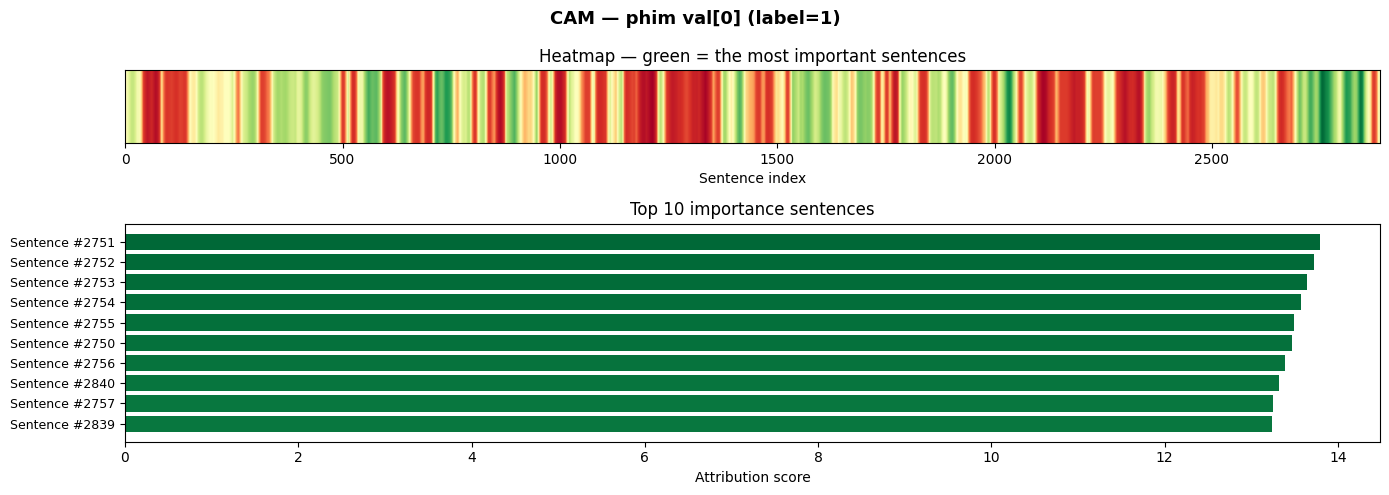

In [206]:
plot_attribution(cam, n_sentences=len(val_emb[0]),
                     title=f"CAM — phim val[0] (label={target_class})")

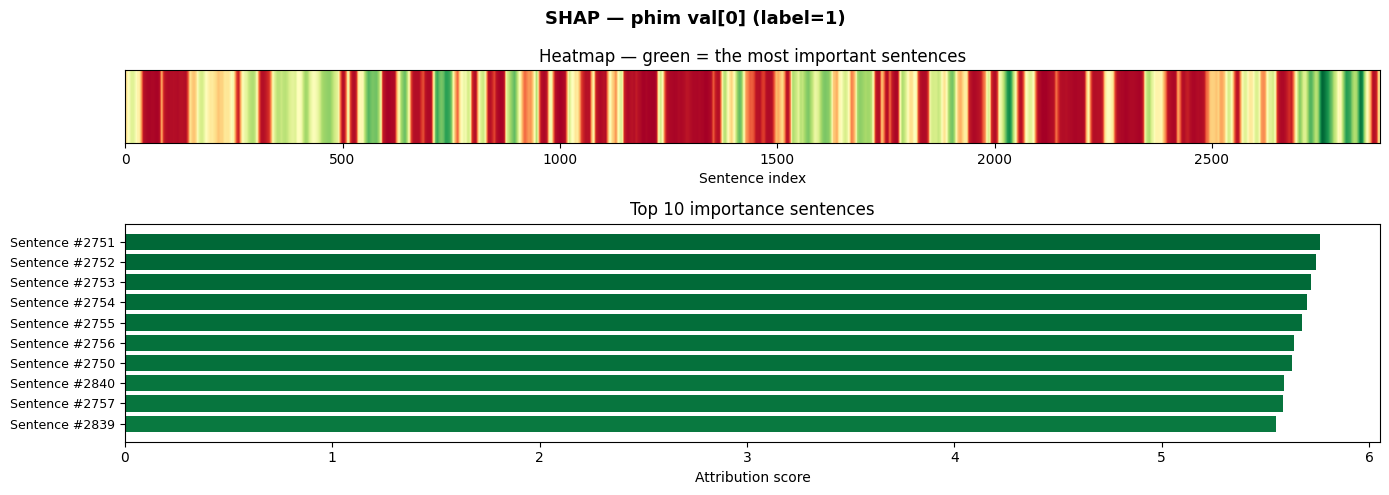

In [207]:
plot_attribution(shap_attr, n_sentences=len(val_emb[0]),
                     title=f"SHAP — phim val[0] (label={target_class})")
#plt.savefig("shap_attribution.png", dpi=150, bbox_inches="tight")

In [213]:
def plot_attribution_with_sentences(attribution, sentences, title="Attribution", top_k=10):
    n         = len(sentences)
    src_x     = np.linspace(0, n - 1, len(attribution))
    attr_full = np.interp(np.arange(n), src_x, attribution)
    attr_norm = (attr_full - attr_full.min()) / (attr_full.max() - attr_full.min() + 1e-8)

    top_idx = np.argsort(attr_full)[-top_k:][::-1]

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    for rank, i in enumerate(top_idx):
        score = attr_full[i]
        bar   = "█" * int(attr_norm[i] * 20)
        print(f"\nRank {rank+1} | Câu #{i} | score={score:.4f}")
        print(f"{bar}")
        print(f"→ {sentences[i]}")
    print(f"{'='*60}\n")

In [214]:
sentences = df.iloc[val_idx[0]]["sentences"] 
plot_attribution_with_sentences(cam, sentences)


Attribution

Rank 1 | Câu #2751 | score=13.7952
███████████████████
→ pumpkin is that what i think it is?

Rank 2 | Câu #2752 | score=13.7201
███████████████████
→ jules nods his head: "yes."

Rank 3 | Câu #2753 | score=13.6449
███████████████████
→ pumpkin it's beautiful.

Rank 4 | Câu #2754 | score=13.5698
███████████████████
→ jules nods his head: "yes."

Rank 5 | Câu #2755 | score=13.4947
███████████████████
→ honey bunny goddammit, what is it?

Rank 6 | Câu #2750 | score=13.4724
███████████████████
→ what is it?

Rank 7 | Câu #2756 | score=13.3850
███████████████████
→ jules slams the case closed, then sits back, as if offering the case to pumpkin.

Rank 8 | Câu #2840 | score=13.3203
███████████████████
→ jules put it in your pocket, it's yours.

Rank 9 | Câu #2757 | score=13.2464
███████████████████
→ pumpkin, one big smile, bends over to pick up the case.

Rank 10 | Câu #2839 | score=13.2369
███████████████████
→ pumpkin about fifteen hundred dollars.



In [215]:
plot_attribution_with_sentences(shap_attr, sentences)


Attribution

Rank 1 | Câu #2751 | score=5.7640
███████████████████
→ pumpkin is that what i think it is?

Rank 2 | Câu #2752 | score=5.7421
███████████████████
→ jules nods his head: "yes."

Rank 3 | Câu #2753 | score=5.7202
███████████████████
→ pumpkin it's beautiful.

Rank 4 | Câu #2754 | score=5.6983
███████████████████
→ jules nods his head: "yes."

Rank 5 | Câu #2755 | score=5.6764
███████████████████
→ honey bunny goddammit, what is it?

Rank 6 | Câu #2756 | score=5.6375
███████████████████
→ jules slams the case closed, then sits back, as if offering the case to pumpkin.

Rank 7 | Câu #2750 | score=5.6264
███████████████████
→ what is it?

Rank 8 | Câu #2840 | score=5.5871
███████████████████
→ jules put it in your pocket, it's yours.

Rank 9 | Câu #2757 | score=5.5846
███████████████████
→ pumpkin, one big smile, bends over to pick up the case.

Rank 10 | Câu #2839 | score=5.5526
███████████████████
→ pumpkin about fifteen hundred dollars.



## ADDITIONAL VISUALIZATION

In [81]:
def plot_rating_distribution(df, save_path="rating_distribution.png"):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw rating distribution
    axes[0].hist(df["averageRating"], bins=30,
                 color="#4575b4", edgecolor="white", alpha=0.85)
    axes[0].axvline(7.0, color="#d73027", linewidth=2,
                    linestyle="--", label="Threshold (7.0)")
    axes[0].set_xlabel("Average Rating", fontsize=11)
    axes[0].set_ylabel("Number of Movies", fontsize=11)
    axes[0].set_title("Rating Distribution", fontsize=12, fontweight="bold")
    axes[0].legend(fontsize=10)
    axes[0].xaxis.grid(True, linestyle="--", alpha=0.4)

    # Class balance
    counts = df["rating_label"].value_counts().sort_index()
    bars   = axes[1].bar(["Bad Movie (0)", "Good Movie (1)"],
                          counts.values,
                          color=["#d73027", "#4575b4"],
                          edgecolor="white", alpha=0.85)
    for bar, val in zip(bars, counts.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1,
                     f"{val}\n({val/len(df)*100:.1f}%)",
                     ha="center", va="bottom", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Number of Movies", fontsize=11)
    axes[1].set_title("Class Distribution (rating >= 7 = Good)",
                       fontsize=12, fontweight="bold")
    axes[1].yaxis.grid(True, linestyle="--", alpha=0.4)

    fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  [Saved] Rating distribution → {save_path}")

plot_rating_distribution(df)

  [Saved] Rating distribution → rating_distribution.png


In [82]:
def plot_sentence_distribution(df, save_path="sentence_distribution.png"):
    import matplotlib.pyplot as plt

    df["n_sentences"] = df["sentences"].apply(len)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Overall distribution
    axes[0].hist(df["n_sentences"], bins=40,
                 color="#4575b4", edgecolor="white", alpha=0.85)
    axes[0].set_xlabel("Number of Sentences per Script", fontsize=11)
    axes[0].set_ylabel("Number of Movies", fontsize=11)
    axes[0].set_title("Sentence Count Distribution", fontsize=12, fontweight="bold")
    axes[0].xaxis.grid(True, linestyle="--", alpha=0.4)

    # By class
    good = df[df["rating_label"] == 1]["n_sentences"]
    bad  = df[df["rating_label"] == 0]["n_sentences"]
    axes[1].hist(good, bins=30, alpha=0.7, color="#4575b4", label="Good Movie (1)")
    axes[1].hist(bad,  bins=30, alpha=0.7, color="#d73027", label="Bad Movie (0)")
    axes[1].set_xlabel("Number of Sentences per Script", fontsize=11)
    axes[1].set_ylabel("Number of Movies", fontsize=11)
    axes[1].set_title("Sentence Count by Class", fontsize=12, fontweight="bold")
    axes[1].legend(fontsize=10)
    axes[1].xaxis.grid(True, linestyle="--", alpha=0.4)

    fig.suptitle("Script Length Analysis", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  [Saved] Sentence distribution → {save_path}")

plot_sentence_distribution(df)

  [Saved] Sentence distribution → sentence_distribution.png
